In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
from torchvision.datasets import CIFAR10
from torchvision.transforms import ToTensor
from torch.utils.data.dataloader import DataLoader
from sklearn.metrics import classification_report
from scipy.stats import entropy
from time import time
from torch.utils.data import random_split

In [2]:
num_classes = 10
num_layers = 5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(42)
dataset = CIFAR10(root="./data", download=True, transform=ToTensor())
test_dataset = CIFAR10(root="./data", train=False, transform=ToTensor())

batch_size = 128
val_size = 5000
train_size = len(dataset) - val_size
_, val_ds = random_split(dataset, [train_size, val_size])
val_loader = DataLoader(val_ds, batch_size * 2, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size * 2, num_workers=4)

Files already downloaded and verified


In [3]:
class Branch(nn.Module):
    def __init__(self, in_channels, in_features):
        super(Branch, self).__init__()
        self.conv = nn.Conv2d(
            in_channels=in_channels, out_channels=16, kernel_size=3, stride=2
        )
        self.bn = nn.BatchNorm2d(num_features=16)
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(in_features=in_features, out_features=num_classes)

    def forward(self, x):
        x = self.conv(x)
        x = F.relu(x)
        x = self.bn(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x

In [4]:
class Baseline(nn.Module):
    def __init__(self):
        super(Baseline, self).__init__()
        self.in_channels = [32, 32, 64, 64, 128]
        self.in_features = [3600, 784, 784, 144, 144]
        self.conv1 = nn.Conv2d(
            in_channels=3, out_channels=32, kernel_size=3, padding="same"
        )
        self.conv2 = nn.Conv2d(
            in_channels=32, out_channels=32, kernel_size=3, padding="same"
        )
        self.pool1 = nn.MaxPool2d(kernel_size=2)
        self.bn1 = nn.BatchNorm2d(num_features=32)
        self.bn2 = nn.BatchNorm2d(num_features=32)
        self.dropout1 = nn.Dropout(p=0.2)

        self.conv3 = nn.Conv2d(
            in_channels=32, out_channels=64, kernel_size=3, padding="same"
        )
        self.conv4 = nn.Conv2d(
            in_channels=64, out_channels=64, kernel_size=3, padding="same"
        )
        self.pool2 = nn.MaxPool2d(kernel_size=2)
        self.bn3 = nn.BatchNorm2d(num_features=64)
        self.bn4 = nn.BatchNorm2d(num_features=64)
        self.dropout2 = nn.Dropout(p=0.3)

        self.conv5 = nn.Conv2d(
            in_channels=64, out_channels=128, kernel_size=3, padding="same"
        )
        self.conv6 = nn.Conv2d(
            in_channels=128, out_channels=128, kernel_size=3, padding="same"
        )
        self.pool3 = nn.MaxPool2d(kernel_size=2)
        self.bn5 = nn.BatchNorm2d(num_features=128)
        self.bn6 = nn.BatchNorm2d(num_features=128)
        self.dropout3 = nn.Dropout(p=0.4)

        self.branch1 = Branch(
            in_channels=self.in_channels[0], in_features=self.in_features[0]
        )
        self.branch2 = Branch(
            in_channels=self.in_channels[1], in_features=self.in_features[1]
        )
        self.branch3 = Branch(
            in_channels=self.in_channels[2], in_features=self.in_features[2]
        )
        self.branch4 = Branch(
            in_channels=self.in_channels[3], in_features=self.in_features[3]
        )
        self.branch5 = Branch(
            in_channels=self.in_channels[4], in_features=self.in_features[4]
        )

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(in_features=2048, out_features=128)
        self.fc2 = nn.Linear(in_features=128, out_features=128)
        self.fc3 = nn.Linear(in_features=128, out_features=128)
        self.fc4 = nn.Linear(in_features=128, out_features=128)
        self.bn7 = nn.BatchNorm1d(num_features=128)
        self.dropout4 = nn.Dropout(p=0.5)
        self.fc5 = nn.Linear(in_features=128, out_features=num_classes)

        self.num_layers = num_layers

    def forward(self, tensor_after_previous_layer, exit_layer_idx=num_layers):
        if exit_layer_idx == 0:
            x = self.conv1(tensor_after_previous_layer)
            x = F.relu(x)
            tensor_after_layer = self.bn1(x)
            predicted_scores_from_layer = self.branch1(tensor_after_layer)

        elif exit_layer_idx == 1:
            x = self.conv2(tensor_after_previous_layer)
            x = F.relu(x)
            x = self.bn2(x)
            x = self.pool1(x)
            tensor_after_layer = self.dropout1(x)
            predicted_scores_from_layer = self.branch2(tensor_after_layer)

        elif exit_layer_idx == 2:
            x = self.conv3(tensor_after_previous_layer)
            x = F.relu(x)
            tensor_after_layer = self.bn3(x)
            predicted_scores_from_layer = self.branch3(tensor_after_layer)

        elif exit_layer_idx == 3:
            x = self.conv4(tensor_after_previous_layer)
            x = F.relu(x)
            x = self.bn4(x)
            x = self.pool2(x)
            tensor_after_layer = self.dropout2(x)
            predicted_scores_from_layer = self.branch4(tensor_after_layer)

        elif exit_layer_idx == 4:
            x = self.conv5(tensor_after_previous_layer)
            x = F.relu(x)
            tensor_after_layer = self.bn5(x)
            predicted_scores_from_layer = self.branch5(tensor_after_layer)

        elif exit_layer_idx == 5:
            x = self.conv6(tensor_after_previous_layer)
            x = F.relu(x)
            x = self.bn6(x)
            x = self.pool3(x)
            x = self.dropout3(x)

            x = self.flatten(x)
            x = self.fc1(x)
            x = F.relu(x)
            x = self.fc2(x)
            x = F.relu(x)
            x = self.fc3(x)
            x = F.relu(x)
            x = self.fc4(x)
            x = F.relu(x)
            x = self.bn7(x)
            tensor_after_layer = self.dropout4(x)
            predicted_scores_from_layer = self.fc5(tensor_after_layer)

        else:
            ValueError(f"exit_layer_idx {exit_layer_idx} should be int within 0 to 5")

        return tensor_after_layer, predicted_scores_from_layer

In [5]:
model = Baseline().to(device)
model.load_state_dict(torch.load("cifar10_branchyNet_m.h5", map_location="cuda"))
model.eval()


def cutoff_exit_performance_check(cutoff, print_per_layer_performance=False):
    """
    TODO: On test data, run the model by iterating through exit layer indices.
    Decide, based on entropy, whether to exit from a particular layer or not.
    Please utilize tensors  after a layer for the next layer, if not exited.
    If print_per_layer_performance is True, please print accuracy and time
    for each layer. We want to see the printables for only one value. When
    plotting, you don't need to print these.
    """

    model.eval()
    total_samples = 0
    layer_correct = [0] * num_layers
    layer_samples = [0] * num_layers
    layer_times = [0.0] * num_layers
    
    final_predictions = torch.zeros(len(test_dataset), dtype=torch.long).to(device)
    remaining_indices = torch.arange(len(test_dataset)).to(device)
    
    with torch.no_grad():
        for batch_idx, (data, labels) in enumerate(test_loader):
            data, labels = data.to(device), labels.to(device)
            batch_size = data.size(0)
            batch_indices = remaining_indices[batch_idx*batch_size : (batch_idx+1)*batch_size]
            
            current_data = data
            current_output = None
            current_entropy = None
            
            for layer_idx in range(num_layers):
                start_time = time()
                
                # Forward pass through current layer
                current_data, current_output = model(current_data, exit_layer_idx=layer_idx)
                probs = F.softmax(current_output, dim=1)
                current_entropy = entropy(probs.cpu().numpy(), axis=1)
                
                # Decide which samples to exit
                exit_decisions = torch.tensor(current_entropy <= cutoff, device=device)
                layer_time = time() - start_time
                
                # Update statistics for samples that exit at this layer
                if exit_decisions.any():
                    exiting_samples = exit_decisions.nonzero().squeeze(1)
                    final_predictions[batch_indices[exiting_samples]] = torch.argmax(current_output[exiting_samples], dim=1)
                    layer_correct[layer_idx] += (final_predictions[batch_indices[exiting_samples]] == 
                                              labels[exiting_samples]).sum().item()
                    layer_samples[layer_idx] += exiting_samples.size(0)
                    layer_times[layer_idx] += layer_time * exiting_samples.size(0)
                
                # Continue with remaining samples
                if (~exit_decisions).all():
                    break
                elif (~exit_decisions).any():
                    continue_data = current_data[~exit_decisions]
                    continue_labels = labels[~exit_decisions]
                    continue_indices = batch_indices[~exit_decisions]
                    current_data = continue_data
                    labels = continue_labels
                    batch_indices = continue_indices
                else:
                    break
    
    # Calculate overall statistics
    total_correct = sum(layer_correct)
    total_samples = len(test_dataset)
    overall_accuracy = total_correct / total_samples
    total_time = sum(layer_times)
    
    if print_per_layer_performance:
        print(f"Cutoff: {cutoff}")
        print("Layer\tAccuracy\tTime (s)")
        for layer_idx in range(num_layers):
            if layer_samples[layer_idx] > 0:
                acc = layer_correct[layer_idx] / layer_samples[layer_idx]
                print(f"{layer_idx}\t{acc:.4f}\t\t{layer_times[layer_idx]:.4f}")
        print(f"Overall accuracy: {overall_accuracy:.4f}")
        print(f"Total time: {total_time:.4f} seconds")
    
    return overall_accuracy, total_time



C:\Users\mtlun\AppData\Local\Temp\ipykernel_18684\4058453171.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("cifar10_branchyNet_m.h5", 

In [6]:
def estimate_thresholds(desired_accuracy):
    """
    TODO: On validation data, for each layer, estimate entropy cutoff that
    gives the desired accuracy. Consider the samples exited and skip those
    samples when estimating the thresholds for the following layers.
    """
    model.eval()
    thresholds = []
    all_samples_processed = torch.zeros(len(val_ds), dtype=torch.bool).to(device)
    
    for layer_idx in range(num_layers):
        layer_entropies = []
        layer_correct = []
        sample_indices = []
        
        with torch.no_grad():
            for batch_idx, (data, labels) in enumerate(val_loader):
                data, labels = data.to(device), labels.to(device)
                batch_indices = torch.arange(
                    batch_idx * val_loader.batch_size,
                    min((batch_idx+1)*val_loader.batch_size, len(val_ds)),
                    device=device
                )
                
                # Skip samples that already exited at earlier layers
                active_mask = ~all_samples_processed[batch_indices]
                if not active_mask.any():
                    continue
                    
                active_data = data[active_mask]
                active_labels = labels[active_mask]
                active_indices = batch_indices[active_mask]
                
                # Process through all previous layers first
                current_data = active_data
                for prev_layer in range(layer_idx):
                    current_data, _ = model(current_data, exit_layer_idx=prev_layer)
                
                # Now get output for current layer
                _, current_output = model(current_data, exit_layer_idx=layer_idx)
                probs = F.softmax(current_output, dim=1)
                entropies = torch.tensor(entropy(probs.cpu().numpy(), axis=1), device=device)
                preds = torch.argmax(current_output, dim=1)
                
                layer_entropies.append(entropies)
                layer_correct.append(preds == active_labels)
                sample_indices.append(active_indices)
        
        if not layer_entropies:
            thresholds.append(0.0)  # No samples reached this layer
            continue
            
        layer_entropies = torch.cat(layer_entropies)
        layer_correct = torch.cat(layer_correct)
        sample_indices = torch.cat(sample_indices)
        
        # Sort samples by entropy
        sorted_entropies, sort_idx = torch.sort(layer_entropies)
        sorted_correct = layer_correct[sort_idx]
        sorted_indices = sample_indices[sort_idx]
        
        # Find threshold where cumulative accuracy >= desired_accuracy
        cum_acc = torch.cumsum(sorted_correct.float(), dim=0) / torch.arange(
            1, len(sorted_correct)+1, device=device)
        valid = cum_acc >= desired_accuracy
        if valid.any():
            threshold_idx = torch.where(valid)[0][0]
            threshold = sorted_entropies[threshold_idx].item()
            
            # Mark samples that would exit at this threshold
            exiting_samples = sorted_indices[sorted_entropies <= threshold]
            all_samples_processed[exiting_samples] = True
        else:
            threshold = sorted_entropies[-1].item()  # If can't meet accuracy, use max
        
        thresholds.append(threshold)
    
    return thresholds


In [14]:
# TODO: 1(a) For a fixed value of cutoff, show performance for all layers.

cutoff = 0.6
overall_acc, total_time = cutoff_exit_performance_check(cutoff, print_per_layer_performance=True)

Cutoff: 0.6
Layer	Accuracy	Time (s)
0	0.8093		20.1782
1	0.8719		4.9884
2	0.8320		3.4393
3	0.8009		1.0663
4	0.8028		1.1824
Overall accuracy: 0.7057
Total time: 30.8546 seconds


In [18]:
# TODO: 1(b) Plot overall accuracy vs cutoff, total time vs cutoff
# and total time vs overall accuracy.
import numpy as np

total_times = []
total_accs = []

cutoffs = np.linspace(0.1, 10, 100)

for cutoff in cutoffs:
    overall_acc, total_time = cutoff_exit_performance_check(cutoff, print_per_layer_performance=False)
    total_times.append(total_time)
    total_accs.append(overall_acc)

print("Total Times and Accuracies for Cutoffs Completed")

KeyboardInterrupt: 

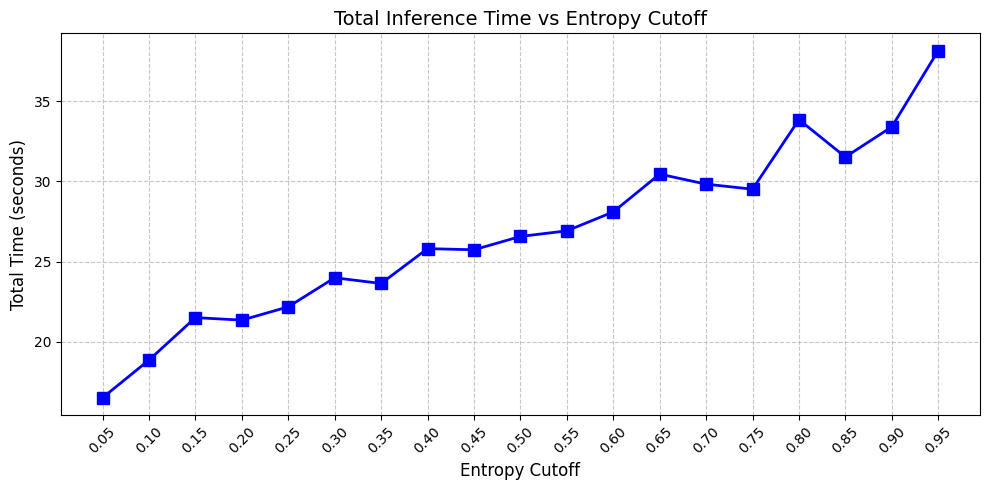

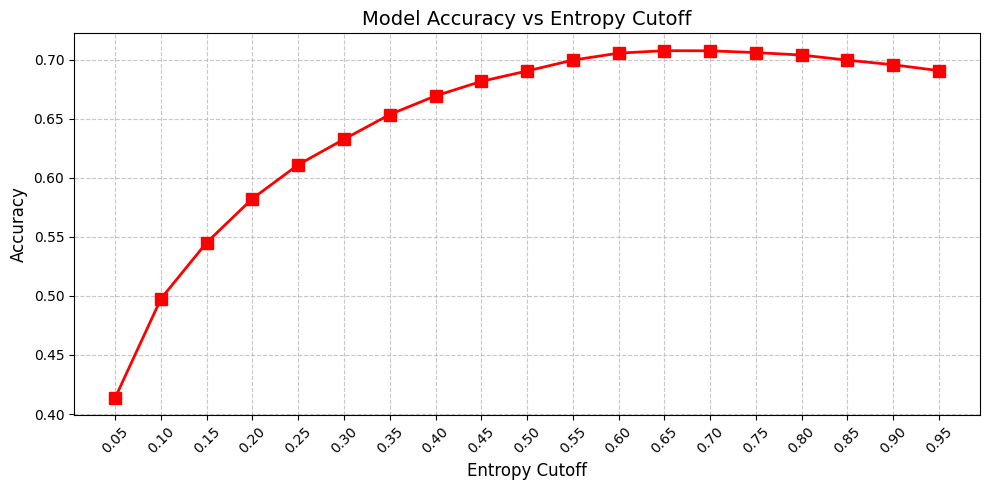

In [ ]:
import matplotlib.pyplot as plt

# Plot Total Time vs Cutoff
plt.figure(figsize=(10, 5))
plt.plot(cutoffs, total_times, 'b-s', linewidth=2, markersize=8)
plt.title("Total Inference Time vs Entropy Cutoff", fontsize=14)
plt.xlabel("Entropy Cutoff", fontsize=12)
plt.ylabel("Total Time (seconds)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(cutoffs, rotation=45)
plt.tight_layout()
plt.show()

# Plot Accuracy vs Cutoff
plt.figure(figsize=(10, 5))
plt.plot(cutoffs, total_accs, 'r-s', linewidth=2, markersize=8)
plt.title("Model Accuracy vs Entropy Cutoff", fontsize=14)
plt.xlabel("Entropy Cutoff", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(cutoffs, rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# TODO: 2(a) On validation data, estimate threshold for each layer based on
# desired minimum accuracy. Use said list of thresholds on test data.

#Validation Data Loader Sanity Check
val_loader = DataLoader(val_ds, batch_size*2, num_workers=4)

# Run threshold estimation
desired_acc = 0.80  # 80% minimum accuracy target
print(f"Estimating thresholds for {desired_acc*100:.0f}% minimum accuracy...")
thresholds = estimate_thresholds(desired_acc)
print(f"Estimated thresholds: {thresholds}")

Estimating thresholds for 85% minimum accuracy...
Estimated thresholds: [8.483663805236574e-06, 0.00014676523278467357, 3.861084223899525e-06, 8.072011041804217e-06, 1.6174965367099503e-08]


In [ ]:
def evaluate_with_thresholds(thresholds, print_per_layer=False):
    
    #Evaluate model on test data using estimated thresholds
    
    model.eval()
    layer_correct = [0] * num_layers
    layer_counts = [0] * num_layers
    total_correct = 0
    
    with torch.no_grad():
        for data, labels in test_loader:
            data, labels = data.to(device), labels.to(device)
            current_data = data
            
            for layer_idx in range(num_layers):
                if current_data.size(0) == 0:
                    break
                
                # Process through current layer
                tensor_after_layer, current_output = model(current_data, exit_layer_idx=layer_idx)
                probs = F.softmax(current_output, dim=1)
                entropies = torch.tensor(entropy(probs.cpu().numpy(), axis=1), device=device)
                preds = torch.argmax(current_output, dim=1)
                
                exit_mask = entropies <= thresholds[layer_idx]
                
                if exit_mask.any():
                    layer_correct[layer_idx] += (preds[exit_mask] == labels[exit_mask]).sum().item()
                    layer_counts[layer_idx] += exit_mask.sum().item()
                    total_correct += (preds[exit_mask] == labels[exit_mask]).sum().item()
                
                # Continue with remaining samples
                continue_mask = ~exit_mask
                if continue_mask.any():
                    current_data = tensor_after_layer[continue_mask]
                    labels = labels[continue_mask]
                else:
                    break
    
    if print_per_layer:
        print("Layer\tAccuracy\tSamples")
        for i in range(num_layers):
            if layer_counts[i] > 0:
                acc = layer_correct[i] / layer_counts[i]
                print(f"{i}\t{acc:.4f}\t\t{layer_counts[i]}")
    
    total_samples = sum(layer_counts)
    overall_acc = total_correct / total_samples if total_samples > 0 else 0
    return overall_acc

In [ ]:
print("\nEvaluating on test data with these thresholds:")
test_acc = evaluate_with_thresholds(thresholds, print_per_layer=True)
print(f"\nOverall test accuracy: {test_acc:.4f}")


Evaluating on test data with these thresholds:
Layer	Accuracy	Samples
3	1.0000		1

Overall test accuracy: 1.0000


In [ ]:
# TODO: 2(c) Vary the desired minimum accuracy and generate lists of
# thresholds. For the list of list of thresholds, plot total time
# vs overall accuracy.

def thresholds_on_cutoff_perf(cutoff_list):
    times = []
    accs = []
    
    for cutoff in cutoff_list:
        overall_acc, total_time = cutoff_exit_performance_check(cutoff, print_per_layer_performance=True)
        times.append(total_time)
        accs.append(overall_acc)

    return accs, times

minimum_accs = np.linspace(0.01, 1, 100)

total_times = []
thresholds = []
for acc in minimum_accs:
    start_time = time()
    
    thresholds.append(estimate_thresholds(acc))
    
    end_time = time()

    total_time = end_time - start_time

    total_times.append(total_time)

    print(f"Minimum Accuracy: {acc}, Total Time: {total_time:.4f} seconds")

#Plot Total Time vs Overall Accuracy
plt.figure(figsize=(10, 5))
plt.plot(thresholds, total_times, 'g-s', linewidth=2, markersize=8)
plt.title("Total Inference Time vs Overall Accuracy", fontsize=14)
plt.xlabel("Overall Accuracy", fontsize=12)
plt.ylabel("Total Time (seconds)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)


Minimum Accuracy: 0.05, Total Time: 102.4337 seconds


KeyboardInterrupt: 

In [ ]:
#Best thresholds from minimum 0.95 (Fastest execution time)

best_thresholds = estimate_thresholds(0.95)

acc = evaluate_with_thresholds(best_thresholds, print_per_layer=True)
print(f"\nOverall test accuracy: {test_acc:.4f}")


Layer	Accuracy	Samples
3	1.0000		1

Overall test accuracy: 1.0000
